# Theorem 3 TD-QNN 3D comparison

This notebook trains the Theorem 3 TD-QNN model on an explicit tensor-decomposed polynomial target and saves the final comparison figure as `theorem3_td_qnn_3d_comparison.png`.


In [165]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 5
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_default_dtype(torch.float64)

D = 2
R = 4
L = 3
N_TRAIN = 2000
ADAM_EPOCHS = 2500
LEARNING_RATE = 1e-1
OUTPUT_PATH = "theorem3_td_qnn_3d_comparison.png"

lambda_i = torch.tensor([0.35, 0.25, 0.25, 0.15], dtype=torch.float64)
target_coeffs = torch.tensor(
    [
        [[-0.50, 0.00, 1.00, 0.00], [0.00, -1.50, 0.00, 2.00]],
        [[0.00, -1.50, 0.00, 2.00], [0.00, 0.50, 0.00, 0.00]],
        [[0.50, 0.00, 0.00, 0.00], [-0.50, 0.00, 1.00, 0.00]],
        [[0.00, 0.50, 0.00, 0.00], [0.00, -1.50, 0.00, 2.00]],
    ],
    dtype=torch.float64,
)

Lambda = lambda_i.abs().sum()
assert lambda_i.shape == (R,)
assert target_coeffs.shape == (R, D, L + 1)
assert abs(Lambda.item() - 1.0) < 1e-12

# Random QNN initialization. These are not part of the target definition.
init_theta_ij_1 = 2.0 * math.pi * torch.randn(R, D, L) * 0.45
init_theta_ij_2 = 2.0 * math.pi * torch.randn(R, D, L + 1) * 0.45
init_lambda_i = torch.rand(R, dtype=torch.float64) + 0.1
init_lambda_i = init_lambda_i / init_lambda_i.abs().sum()

assert init_theta_ij_1.shape == (R, D, L)
assert init_theta_ij_2.shape == (R, D, L + 1)
assert init_lambda_i.shape == (R,)

S_N_WIRES = 2 * D
S_DIM = 2 ** S_N_WIRES
SINGLE_I_N_WIRES = 1 + 2 * D
A_N_WIRES = math.ceil(math.log2(R))
W_P_N_WIRES = 1 + A_N_WIRES + 2 * D
if 2 ** A_N_WIRES != R:
    raise ValueError("This verification expects R to be a power of two.")

A_WIRES = list(range(1, 1 + A_N_WIRES))
S_OFFSET = 1 + A_N_WIRES

print(f"D={D}, R={R}, L={L}")
print(f"N_TRAIN={N_TRAIN}, ADAM_EPOCHS={ADAM_EPOCHS}")
print(f"torch simulator wires={S_N_WIRES}, dim(S)={S_DIM}")


D=2, R=4, L=3
N_TRAIN=2000, ADAM_EPOCHS=2500
torch simulator wires=4, dim(S)=16


## PennyLane verification circuit

The PennyLane implementation follows the proof of Theorem 3. It is used only to verify that the batched torch simulator agrees with the intended quantum circuit.


In [166]:
def S_qml(x_j, wire):
    qml.RX(-2 * torch.arccos(x_j), wires=wire)


def U_theta_qml(theta, x_j, wire):
    qml.RZ(theta[0], wires=wire)
    for phase in theta[1:]:
        S_qml(x_j, wire)
        qml.RZ(phase, wires=wire)


def V_i_S_qml(x, theta_i_1, theta_i_2):
    for j in range(D):
        selector_wire = 1 + 2 * j
        qsp_wire = 2 + 2 * j
        qml.PauliX(wires=selector_wire)
        qml.ctrl(U_theta_qml, control=selector_wire)(theta_i_1[j], x[j], qsp_wire)
        qml.PauliX(wires=selector_wire)
        qml.ctrl(U_theta_qml, control=selector_wire)(theta_i_2[j], x[j], qsp_wire)


single_i_dev = qml.device("default.qubit", wires=SINGLE_I_N_WIRES)


@qml.qnode(single_i_dev, interface="torch", diff_method="backprop")
def V_i_hadamard_test_qml(x, theta_i_1, theta_i_2):
    for wire in range(SINGLE_I_N_WIRES):
        qml.Hadamard(wires=wire)
    qml.ctrl(V_i_S_qml, control=0)(x, theta_i_1, theta_i_2)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(wires=0))


def F_A_qml(lambda_i):
    weights = lambda_i.abs()
    amplitudes = torch.sqrt(weights / weights.sum().clamp_min(1e-12)).to(torch.complex128)
    qml.StatePrep(amplitudes, wires=A_WIRES)


def _V_i_S_full_qml(x, theta_i_1, theta_i_2):
    for j in range(D):
        selector_wire = S_OFFSET + 2 * j
        qsp_wire = S_OFFSET + 2 * j + 1
        qml.PauliX(wires=selector_wire)
        qml.ctrl(U_theta_qml, control=selector_wire)(theta_i_1[j], x[j], qsp_wire)
        qml.PauliX(wires=selector_wire)
        qml.ctrl(U_theta_qml, control=selector_wire)(theta_i_2[j], x[j], qsp_wire)


def _V_c_qml(x, theta_ij_1, theta_ij_2):
    for i in range(R):
        a_bits = [int(bit) for bit in format(i, f"0{A_N_WIRES}b")]

        for wire, bit in zip(A_WIRES, a_bits):
            if bit == 0:
                qml.PauliX(wires=wire)

        qml.ctrl(_V_i_S_full_qml, control=A_WIRES)(x, theta_ij_1[i], theta_ij_2[i])

        for wire, bit in zip(A_WIRES, a_bits):
            if bit == 0:
                qml.PauliX(wires=wire)


W_p_dev = qml.device("default.qubit", wires=W_P_N_WIRES)


@qml.qnode(W_p_dev, interface="torch", diff_method="backprop")
def W_p_qml_for_verify(x, theta_ij_1, theta_ij_2, lambda_i):
    qml.Hadamard(wires=0)
    F_A_qml(lambda_i)
    for wire in range(S_OFFSET, W_P_N_WIRES):
        qml.Hadamard(wires=wire)
    qml.ctrl(_V_c_qml, control=0)(x, theta_ij_1, theta_ij_2)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(wires=0))


## Circuit plot

The figure below plots the full $W_p(\boldsymbol{x})$ circuit used for PennyLane verification.


In [167]:
from pennylane import draw_mpl

plot_x = torch.tensor([0.50, -0.25], dtype=torch.float64)

mpl_drawer = draw_mpl(W_p_qml_for_verify)
fig, ax = mpl_drawer(plot_x, init_theta_ij_1, init_theta_ij_2, init_lambda_i)
fig.savefig(
    "theorem3_td_qnn_circuit.png",
    dpi=100,
    bbox_inches="tight",
)
plt.show()


## Batched torch implementation

The torch implementation simulates the $2D$-qubit system register and combines the $i=1,\ldots,R$ tensor terms. It is the only model implementation needed to train and plot the final comparison.


In [168]:
_perm_cache = {}
_pair_cache = {}


def _wire_mask(wire):
    return 1 << (S_N_WIRES - 1 - wire)


def _x_permutation(wire):
    if wire not in _perm_cache:
        _perm_cache[wire] = torch.tensor(
            [idx ^ _wire_mask(wire) for idx in range(S_DIM)],
            dtype=torch.long,
        )
    return _perm_cache[wire]


def _controlled_pairs(target, controls=()):
    key = (target, tuple(controls))
    if key not in _pair_cache:
        idx0, idx1 = [], []
        target_mask = _wire_mask(target)
        for idx in range(S_DIM):
            if idx & target_mask:
                continue
            if all(idx & _wire_mask(control) for control in controls):
                idx0.append(idx)
                idx1.append(idx | target_mask)
        _pair_cache[key] = (
            torch.tensor(idx0, dtype=torch.long),
            torch.tensor(idx1, dtype=torch.long),
        )
    return _pair_cache[key]


def _init_S_plus_state(batch_size):
    return torch.full(
        (batch_size, S_DIM),
        S_DIM ** -0.5,
        dtype=torch.complex128,
    )


def _apply_x(state, wire):
    return state[:, _x_permutation(wire)]


def _apply_controlled_rz(state, controls, target, theta):
    idx0, idx1 = _controlled_pairs(target, controls)
    out = state.clone()
    out[:, idx0] = state[:, idx0] * torch.exp(-0.5j * theta)
    out[:, idx1] = state[:, idx1] * torch.exp(0.5j * theta)
    return out


def _apply_controlled_s(state, controls, target, x_j):
    idx0, idx1 = _controlled_pairs(target, controls)
    out = state.clone()
    amp0 = state[:, idx0]
    amp1 = state[:, idx1]
    x_j = x_j.reshape(-1, 1)
    root = torch.sqrt(torch.clamp(1.0 - x_j * x_j, min=0.0))
    out[:, idx0] = x_j * amp0 + 1j * root * amp1
    out[:, idx1] = 1j * root * amp0 + x_j * amp1
    return out


def _apply_U_theta(state, controls, target, theta, x_j):
    state = _apply_controlled_rz(state, controls, target, theta[0])
    for phase in theta[1:]:
        state = _apply_controlled_s(state, controls, target, x_j)
        state = _apply_controlled_rz(state, controls, target, phase)
    return state


def V_i_expectation_torch(x, theta_i_1, theta_i_2):
    state = _init_S_plus_state(x.shape[0])
    for j in range(D):
        selector_wire = 2 * j
        qsp_wire = 2 * j + 1
        state = _apply_x(state, selector_wire)
        state = _apply_U_theta(state, [selector_wire], qsp_wire, theta_i_1[j], x[:, j])
        state = _apply_x(state, selector_wire)
        state = _apply_U_theta(state, [selector_wire], qsp_wire, theta_i_2[j], x[:, j])
    return state.real.sum(dim=1) * S_DIM ** -0.5


def qnn_output_torch(x, theta_ij_1, theta_ij_2, lambda_i):
    terms = torch.stack(
        [V_i_expectation_torch(x, theta_ij_1[i], theta_ij_2[i]) for i in range(R)],
        dim=1,
    )
    Lambda = lambda_i.abs().sum().clamp_min(1e-12)
    return (terms @ lambda_i) / Lambda


## Verify PennyLane and torch agree

This checks the circuit implementation. It is separate from the definition of the target polynomial, which appears in the next section.


In [169]:
torch.manual_seed(SEED)
verify_x = 2.0 * torch.rand(D) - 1.0
verify_theta_i_1 = init_theta_ij_1[0]
verify_theta_i_2 = init_theta_ij_2[0]

qml_value_i = V_i_hadamard_test_qml(verify_x, verify_theta_i_1, verify_theta_i_2)
torch_value_i = V_i_expectation_torch(verify_x.unsqueeze(0), verify_theta_i_1, verify_theta_i_2)[0]
verification_diff_i = (qml_value_i - torch_value_i).abs().item()

qml_value_W_p = W_p_qml_for_verify(verify_x, init_theta_ij_1, init_theta_ij_2, init_lambda_i)
torch_value_qnn = qnn_output_torch(verify_x.unsqueeze(0), init_theta_ij_1, init_theta_ij_2, init_lambda_i)[0]
verification_diff_W_p = (qml_value_W_p - torch_value_qnn).abs().item()

print(f"PennyLane V^i_S value = {qml_value_i.item(): .16f}")
print(f"torch V^i_S value     = {torch_value_i.item(): .16f}")
print(f"single-i absolute diff = {verification_diff_i:.3e}")
print(f"PennyLane W_p value   = {qml_value_W_p.item(): .16f}")
print(f"torch QNN value       = {torch_value_qnn.item(): .16f}")
print(f"W_p absolute diff     = {verification_diff_W_p:.3e}")
assert verification_diff_i < 1e-10
assert verification_diff_W_p < 1e-10


PennyLane V^i_S value =  0.0343401567013777
torch V^i_S value     =  0.0343401567013776
single-i absolute diff = 4.163e-17
PennyLane W_p value   =  0.0929735588175476
torch QNN value       =  0.0929735588175476
W_p absolute diff     = 4.163e-17


## Target polynomial

The target function is the following TD polynomial from Theorem 3:

$$
p(x_1,x_2)=\sum_{i=1}^{4}\lambda_i p_{i,1}(x_1)p_{i,2}(x_2),
\qquad
(\lambda_1,\lambda_2,\lambda_3,\lambda_4)=(0.35,0.25,0.25,0.15).
$$

Here $\Lambda=\sum_i |\lambda_i|=1$, so no additional scaling is needed. The univariate factors are ordinary polynomials:

$$
\begin{aligned}
p_{1,1}(z)&=z^2-\tfrac12,
&p_{1,2}(z)&=2z^3-\tfrac32 z,\\
p_{2,1}(z)&=2z^3-\tfrac32 z,
&p_{2,2}(z)&=\tfrac12 z,\\
p_{3,1}(z)&=\tfrac12,
&p_{3,2}(z)&=z^2-\tfrac12,\\
p_{4,1}(z)&=\tfrac12 z,
&p_{4,2}(z)&=2z^3-\tfrac32 z.
\end{aligned}
$$

Each univariate factor satisfies the Theorem 3 condition $\max_{z\in[-1,1]} |p_{i,j}(z)|\le \tfrac12$. Equivalently,

$$
\begin{aligned}
p(x_1,x_2)=&\;0.35\,(x_1^2-\tfrac12)(2x_2^3-\tfrac32x_2)
+0.25\,(2x_1^3-\tfrac32x_1)(\tfrac12x_2)\\
&+0.25\,(\tfrac12)(x_2^2-\tfrac12)
+0.15\,(\tfrac12x_1)(2x_2^3-\tfrac32x_2).
\end{aligned}
$$

This is the target. The quantum circuit is only the trainable model used to approximate this polynomial.


In [170]:
def sample_uniform(n, dim):
    return 2.0 * torch.rand(n, dim) - 1.0


def eval_univariate_poly(coeffs, z):
    value = torch.zeros_like(z)
    power = torch.ones_like(z)
    for coeff in coeffs:
        value = value + coeff * power
        power = power * z
    return value


def target_p(x):
    terms = []
    for i in range(R):
        term = lambda_i[i]
        for j in range(D):
            term = term * eval_univariate_poly(target_coeffs[i, j], x[:, j])
        terms.append(term)
    return torch.stack(terms, dim=0).sum(dim=0)


torch.manual_seed(SEED)
x_train = sample_uniform(N_TRAIN, D)

with torch.no_grad():
    y_train = target_p(x_train).unsqueeze(1)


## Train the QNN model


In [171]:
class Theorem3W_p(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta_ij_1 = nn.Parameter(init_theta_ij_1.clone())
        self.theta_ij_2 = nn.Parameter(init_theta_ij_2.clone())
        self.lambda_i = nn.Parameter(init_lambda_i.clone())

    def forward(self, x):
        return qnn_output_torch(x, self.theta_ij_1, self.theta_ij_2, self.lambda_i).unsqueeze(1)


model = Theorem3W_p()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(ADAM_EPOCHS):
    optimizer.zero_grad(set_to_none=True)
    pred = model(x_train)
    train_loss = F.mse_loss(pred, y_train)
    train_loss.backward()
    optimizer.step()

with torch.no_grad():
    final_train_mse = F.mse_loss(model(x_train), y_train).item()

print(f"final train MSE = {final_train_mse:.6e}")


final train MSE = 4.368835e-13


## 3D comparison plot


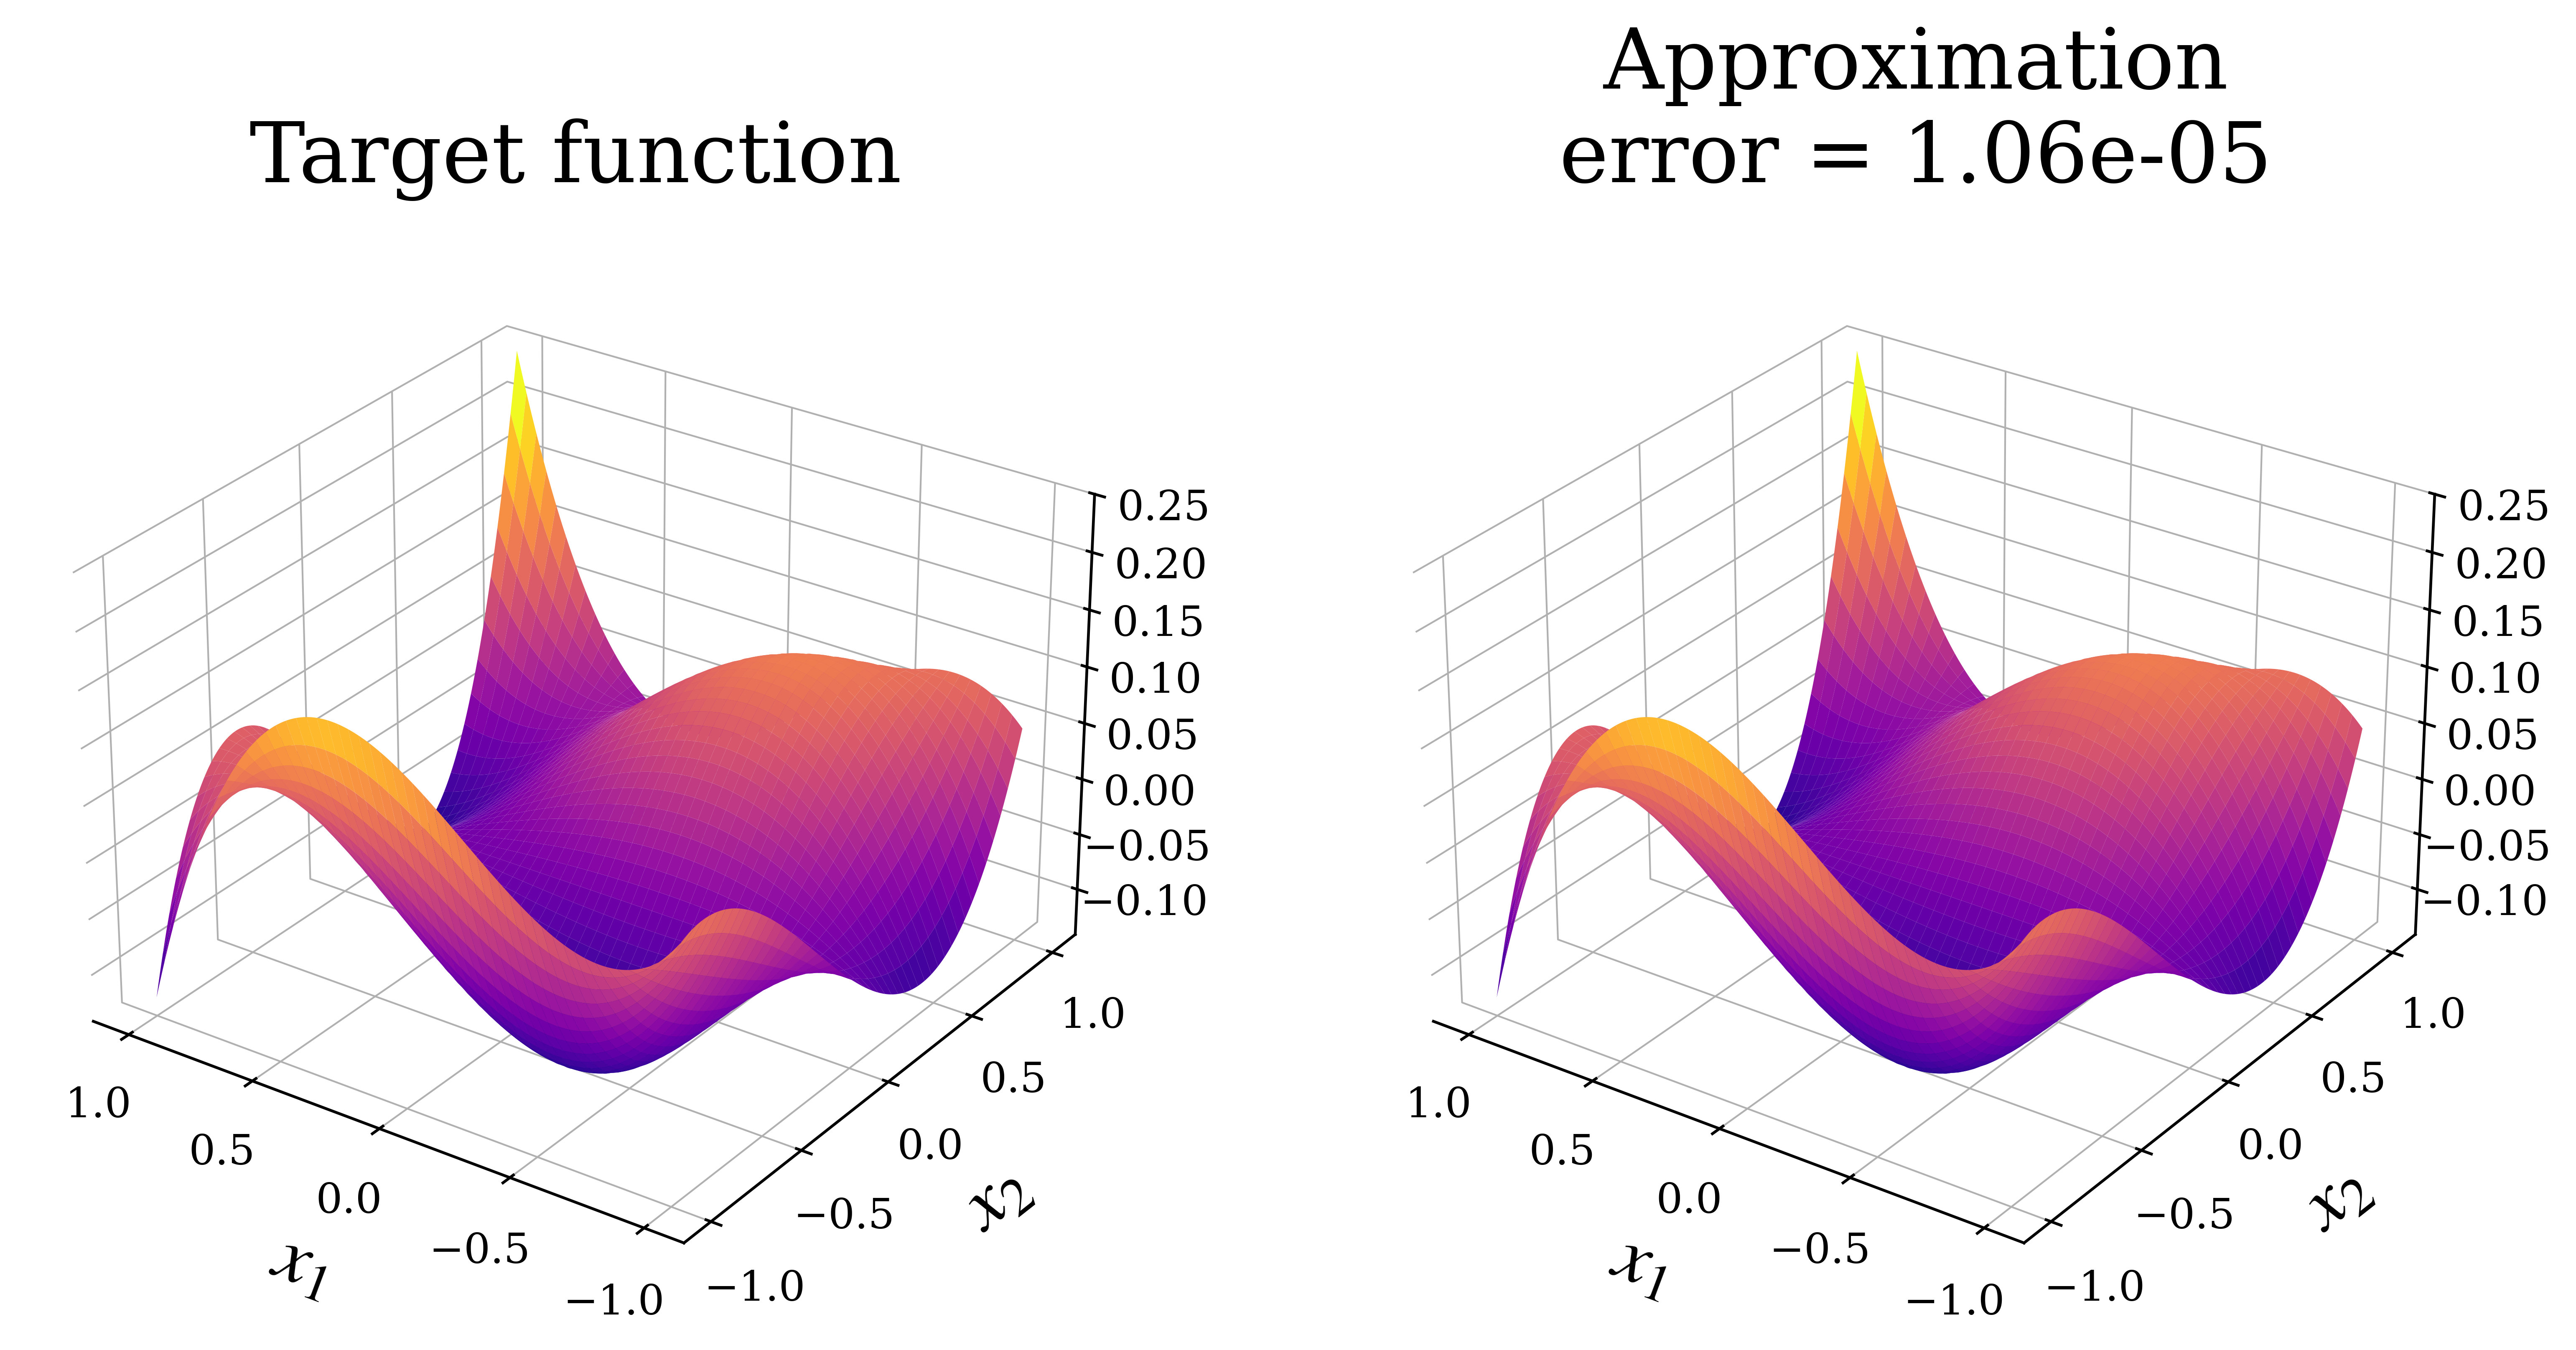

saved theorem3_td_qnn_3d_comparison.png
function-grid relative L2 error = 1.057155e-05
function-grid max abs error     = 9.006817e-06


In [177]:
if D != 2:
    raise ValueError("This 3D comparison is intended for D=2.")

n_grid = 1000
x1 = torch.linspace(-1.0, 1.0, n_grid)
x2 = torch.linspace(-1.0, 1.0, n_grid)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
function_grid_x = torch.zeros(n_grid * n_grid, D)
function_grid_x[:, 0] = X1.reshape(-1)
function_grid_x[:, 1] = X2.reshape(-1)

with torch.no_grad():
    grid_target = target_p(function_grid_x).reshape(n_grid, n_grid)
    grid_qnn = model(function_grid_x).reshape(n_grid, n_grid)
    grid_err = grid_qnn - grid_target

X_np = X1.numpy()
Y_np = X2.numpy()
Z_target = grid_target.detach().numpy()
Z_qnn = grid_qnn.detach().numpy()
Z_err = grid_err.detach().numpy()

relative_l2_grid_error = np.linalg.norm(Z_qnn - Z_target) / np.linalg.norm(Z_target)
max_abs_grid_error = np.max(np.abs(Z_err))
ZMIN = min(Z_target.min(), Z_qnn.min())
ZMAX = max(Z_target.max(), Z_qnn.max())

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 22,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 24,
    "figure.dpi": 600,
})

surf_kwargs = dict(cmap="plasma", edgecolor="none", antialiased=True)


def tidy_surface(ax, title):
    ax.view_init(elev=28, azim=-55)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1, 1, 1, 1))
        axis._axinfo["grid"]["linewidth"] = 0.5
    ax.set_title(title, pad=12)
    ax.set_xlabel(r"$x_1$", labelpad=8)
    ax.set_ylabel(r"$x_2$", labelpad=8)
    ax.set_zlim(ZMIN, ZMAX)
    ax.set_box_aspect((1, 1, 0.7))
    ax.xaxis.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.yaxis.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
    ax.invert_xaxis()


fig = plt.figure(figsize=(11, 5.4), dpi=600)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X_np, Y_np, Z_target, **surf_kwargs)
tidy_surface(ax1, "Target function")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_surface(X_np, Y_np, Z_qnn, **surf_kwargs)
tidy_surface(ax2, f"Approximation\nerror = {relative_l2_grid_error:.2e}")

plt.tight_layout(pad=0.8, w_pad=0.2)
plt.savefig(OUTPUT_PATH, bbox_inches="tight")
plt.show()

print(f"saved {OUTPUT_PATH}")
print(f"function-grid relative L2 error = {relative_l2_grid_error:.6e}")
print(f"function-grid max abs error     = {max_abs_grid_error:.6e}")
